In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split



In [ ]:
df = pd.read_csv('/content/credit_card_fraud_10k.csv')

In [ ]:
print(df.head())

   transaction_id  amount  transaction_hour merchant_category  \
0               1   84.47                22       Electronics   
1               2  541.82                 3            Travel   
2               3  237.01                17           Grocery   
3               4  164.33                 4           Grocery   
4               5   30.53                15              Food   

   foreign_transaction  location_mismatch  device_trust_score  \
0                    0                  0                  66   
1                    1                  0                  87   
2                    0                  0                  49   
3                    0                  1                  72   
4                    0                  0                  79   

   velocity_last_24h  cardholder_age  is_fraud  
0                  3              40         0  
1                  1              64         0  
2                  1              61         0  
3                  3  

In [ ]:
print(df.tail())

      transaction_id  amount  transaction_hour merchant_category  \
9995            9996  350.91                22              Food   
9996            9997  410.04                 5          Clothing   
9997            9998  527.75                21       Electronics   
9998            9999   91.20                 2       Electronics   
9999           10000   44.06                 2          Clothing   

      foreign_transaction  location_mismatch  device_trust_score  \
9995                    0                  0                  99   
9996                    0                  0                  70   
9997                    0                  0                  44   
9998                    0                  0                  38   
9999                    0                  0                  38   

      velocity_last_24h  cardholder_age  is_fraud  
9995                  4              37         0  
9996                  3              25         0  
9997                  2   

In [ ]:
print(df.shape)

(10000, 10)


In [ ]:
print(df.describe())

       transaction_id        amount  transaction_hour  foreign_transaction  \
count     10000.00000  10000.000000      10000.000000         10000.000000   
mean       5000.50000    175.949849         11.593300             0.097800   
std        2886.89568    175.392827          6.922708             0.297059   
min           1.00000      0.000000          0.000000             0.000000   
25%        2500.75000     50.905000          6.000000             0.000000   
50%        5000.50000    122.095000         12.000000             0.000000   
75%        7500.25000    242.480000         18.000000             0.000000   
max       10000.00000   1471.040000         23.000000             1.000000   

       location_mismatch  device_trust_score  velocity_last_24h  \
count       10000.000000        10000.000000       10000.000000   
mean            0.085700           61.798900           2.008900   
std             0.279935           21.487053           1.432559   
min             0.000000     

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB
None


is_fraud
0    9849
1     151
Name: count, dtype: int64


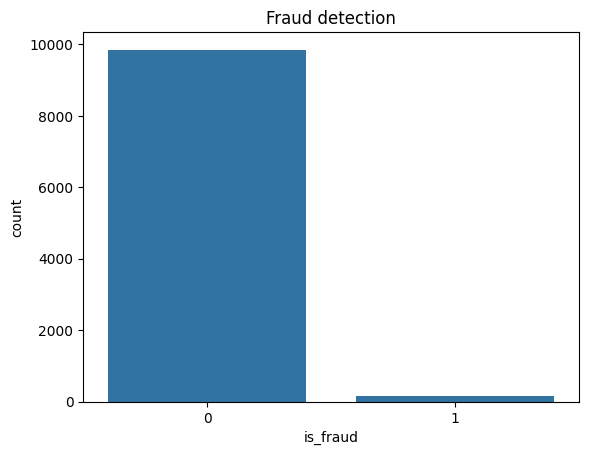

In [ ]:
print(df["is_fraud"].value_counts())
sns.countplot(x="is_fraud",data = df)
plt.title("Fraud detection")
plt.show()

In [ ]:
x = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

In [ ]:
x = pd.get_dummies(
    x,
    columns = ["merchant_category"],
    drop_first = True
)

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(
  x,y,test_size = 0.2,stratify = y,random_state = 42
)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state = 42)
x_train_smote,y_train_smote = smote.fit_resample(
    x_train_scaled,y_train
)
print("Before SMOTE")
print(y_train.value_counts())
print("\nAfter SMOTE")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE
is_fraud
0    7879
1     121
Name: count, dtype: int64

After SMOTE
is_fraud
0    7879
1    7879
Name: count, dtype: int64


In [ ]:
from sklearn.svm import SVC
svm_model = SVC(
    kernel = "rbf",
    random_state = 42,
    probability = True
)

In [ ]:
model = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42
)

In [ ]:
model.fit(x_train_smote , y_train_smote)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(x_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(f1_score(y_test,y_pred))

0.9935
0.8148148148148148
0.7333333333333333
0.7719298245614035
